In [ ]:
# SETUP

from google.colab import drive
drive.mount("/content/drive", force_remount=False)

from pathlib import Path
import json
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

# PROJECT PATHS

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = PROJECT_ROOT / "data"
UNSW_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
CONFIG_DIR = PROJECT_ROOT / "config"

# Save NEW testing results separately
RESULT_DIR = (
    PROJECT_ROOT /
    "results" /
    "gns3_zeek_threshold_budget_sweep"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# NEW PRACTICAL DATASET

X_FILE = (
    DATA_DIR /
    "combined_practical_traffic_v5_41_features.csv"
)

METADATA_FILE = (
    DATA_DIR /
    "combined_practical_traffic_v5_metadata.csv"
)

# Same UNSW normal validation data used for thresholds
VAL_FILE = (
    UNSW_DIR /
    "val_normal.npz"
)

# CHECK FILES

print("41-feature data:", X_FILE.exists())
print("Metadata:", METADATA_FILE.exists())
print("UNSW validation:", VAL_FILE.exists())
print("Result folder:", RESULT_DIR)

Mounted at /content/drive
41-feature data: True
Metadata: True
UNSW validation: True
Result folder: /content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep


In [ ]:
# LOAD GNS3/ZEEK DATA + CREATE NORMAL-ONLY CALIBRATION SPLIT

X_zeek_df = pd.read_csv(X_FILE)
metadata = pd.read_csv(METADATA_FILE)

X_zeek = X_zeek_df.to_numpy(
    dtype=np.float32
)

y_zeek = metadata[
    "label"
].to_numpy(
    dtype=np.int8
)

with np.load(VAL_FILE) as data:
    X_val = data["X"].astype(
        np.float32
    )


print("Full Zeek features:", X_zeek.shape)
print("Metadata:", metadata.shape)

print("\nFULL PRACTICAL DATASET")

print(
    "Normal:",
    int((y_zeek == 0).sum())
)

print(
    "Attack:",
    int((y_zeek == 1).sum())
)

print("\nData sources:")

print(
    metadata["data_source"].value_counts()
)


# CALIBRATION SET
# internal_gns3_v4 = normal-only calibration traffic

calibration_mask = (
    metadata["data_source"]
    == "internal_gns3_v4"
).to_numpy()

calibration_idx = np.flatnonzero(
    calibration_mask
)


# HELD-OUT TEST SET
# Everything except v4

test_idx = np.flatnonzero(
    ~calibration_mask
)

y_test = y_zeek[
    test_idx
]

metadata_test = (
    metadata
    .iloc[test_idx]
    .reset_index(drop=True)
)


print("\nCALIBRATION SET")

print(
    "Records:",
    len(calibration_idx)
)

print(
    "Normal:",
    int(
        (
            y_zeek[
                calibration_idx
            ] == 0
        ).sum()
    )
)

print(
    "Attack:",
    int(
        (
            y_zeek[
                calibration_idx
            ] == 1
        ).sum()
    )
)


print("\nFINAL HELD-OUT TEST SET")

print(
    "Records:",
    len(test_idx)
)

print(
    "Normal:",
    int(
        (y_test == 0).sum()
    )
)

print(
    "Attack:",
    int(
        (y_test == 1).sum()
    )
)


# DATA QUALITY / SPLIT CHECKS

assert X_zeek.shape[1] == 41

assert len(X_zeek) == len(metadata)

assert len(X_zeek) == len(y_zeek)

assert np.isfinite(
    X_zeek
).all()


assert len(X_zeek) == 6966

assert len(
    calibration_idx
) == 1945

assert np.all(
    y_zeek[
        calibration_idx
    ] == 0
)

assert len(
    test_idx
) == 5021

assert int(
    (y_test == 0).sum()
) == 808

assert int(
    (y_test == 1).sum()
) == 4213

assert len(
    np.intersect1d(
        calibration_idx,
        test_idx
    )
) == 0


print(
    "\nCALIBRATION / TEST SPLIT READY"
)

Full Zeek features: (6966, 41)
Metadata: (6966, 9)

FULL PRACTICAL DATASET
Normal: 2753
Attack: 4213

Data sources:
data_source
internal_gns3_v3    1974
internal_gns3_v4    1945
external_laptop     1631
internal_gns3       1416
Name: count, dtype: int64

CALIBRATION SET
Records: 1945
Normal: 1945
Attack: 0

FINAL HELD-OUT TEST SET
Records: 5021
Normal: 808
Attack: 4213

CALIBRATION / TEST SPLIT READY


In [ ]:
# Model and configuration paths

IF_MODEL_FILE = MODEL_DIR / "isolation_forest_candidate1.joblib"
AE_MODEL_FILE = MODEL_DIR / "autoencoder_candidate1.keras"
LOF_MODEL_FILE = MODEL_DIR / "lof_baseline.joblib"
OCSVM_MODEL_FILE = MODEL_DIR / "ocsvm_model.joblib"
DEEP_MODEL_FILE = MODEL_DIR / "deep_svdd_model.pt"

IF_CONFIG_FILE = CONFIG_DIR / "isolation_forest_candidate1.json"
AE_CONFIG_FILE = CONFIG_DIR / "autoencoder_candidate1.json"
LOF_CONFIG_FILE = CONFIG_DIR / "lof_baseline.json"
OCSVM_CONFIG_FILE = CONFIG_DIR / "ocsvm_model.json"
DEEP_CONFIG_FILE = CONFIG_DIR / "deep_svdd_model.json"
HYBRID_CONFIG_FILE = CONFIG_DIR / "hybrid_if_ae.json"

required_files = [
    IF_MODEL_FILE,
    AE_MODEL_FILE,
    LOF_MODEL_FILE,
    OCSVM_MODEL_FILE,
    DEEP_MODEL_FILE,
    IF_CONFIG_FILE,
    AE_CONFIG_FILE,
    LOF_CONFIG_FILE,
    OCSVM_CONFIG_FILE,
    DEEP_CONFIG_FILE,
    HYBRID_CONFIG_FILE
]

for file in required_files:
    print(file.name, "->", file.exists())

if not all(file.exists() for file in required_files):
    raise FileNotFoundError(
        "One or more trained model/configuration files are missing."
    )

isolation_forest_candidate1.joblib -> True
autoencoder_candidate1.keras -> True
lof_baseline.joblib -> True
ocsvm_model.joblib -> True
deep_svdd_model.pt -> True
isolation_forest_candidate1.json -> True
autoencoder_candidate1.json -> True
lof_baseline.json -> True
ocsvm_model.json -> True
deep_svdd_model.json -> True
hybrid_if_ae.json -> True


In [ ]:
# LOAD MODEL CONFIGURATIONS + DEFINE THRESHOLD BUDGET SWEEP

def load_json(path):
    with open(path, "r") as file:
        return json.load(file)


if_config = load_json(IF_CONFIG_FILE)
ae_config = load_json(AE_CONFIG_FILE)
lof_config = load_json(LOF_CONFIG_FILE)
ocsvm_config = load_json(OCSVM_CONFIG_FILE)
deep_config = load_json(DEEP_CONFIG_FILE)
hybrid_config = load_json(HYBRID_CONFIG_FILE)


# NEW THRESHOLD BUDGETS

BUDGETS = [
    "0.5% budget",
    "1% budget",
    "2% budget",
    "3% budget",
    "5% budget",
    "10% budget"
]


def get_thresholds(config):
    return {
        name: float(value)
        for name, value in config["thresholds"].items()
    }


# Old UNSW thresholds are retained only for reference
if_thresholds = get_thresholds(if_config)
ae_thresholds = get_thresholds(ae_config)
lof_thresholds = get_thresholds(lof_config)
ocsvm_thresholds = get_thresholds(ocsvm_config)
deep_thresholds = get_thresholds(deep_config)
hybrid_thresholds = get_thresholds(hybrid_config)


print("GNS3 THRESHOLD BUDGET SWEEP:")
print(BUDGETS)

print("\nOriginal UNSW thresholds retained for reference:")
print("IF:", if_thresholds)
print("AE:", ae_thresholds)
print("LOF:", lof_thresholds)
print("OCSVM:", ocsvm_thresholds)
print("Deep SVDD:", deep_thresholds)
print("Hybrid:", hybrid_thresholds)

GNS3 THRESHOLD BUDGET SWEEP:
['0.5% budget', '1% budget', '2% budget', '3% budget', '5% budget', '10% budget']

Original UNSW thresholds retained for reference:
IF: {'0.5% budget': 0.5676495685072951, '1% budget': 0.5460537691550149, '3% budget': 0.4966390963721801}
AE: {'0.5% budget': 0.04577401398215515, '1% budget': 0.036467666841251495, '3% budget': 0.02375445595651247}
LOF: {'0.5% budget': 1.9827458421041482, '1% budget': 1.8009945299909127, '3% budget': 1.476140406733413}
OCSVM: {'0.5% budget': 0.715225019931776, '1% budget': -5.3313550321087755e-05, '3% budget': -1.0914602100972197}
Deep SVDD: {'0.5% budget': 8.080383850028738e-05, '1% budget': 5.488995884661563e-05, '3% budget': 3.0722618248546496e-05}
Hybrid: {'0.5% budget': 0.9909942047336122, '1% budget': 0.9800818155254699, '3% budget': 0.9389378591604168}


In [ ]:
# Load trained models

if_model = joblib.load(IF_MODEL_FILE)

ae_model = tf.keras.models.load_model(
    AE_MODEL_FILE,
    compile=False
)

lof_model = joblib.load(LOF_MODEL_FILE)
ocsvm_model = joblib.load(OCSVM_MODEL_FILE)

print("Isolation Forest loaded")
print("Autoencoder loaded")
print("LOF loaded")
print("One-Class SVM loaded")

Isolation Forest loaded
Autoencoder loaded
LOF loaded
One-Class SVM loaded


In [ ]:
# Score IF, AE, LOF and OCSVM

if_zeek_scores = -if_model.score_samples(X_zeek)
if_val_scores = -if_model.score_samples(X_val)

ae_zeek_reconstructed = ae_model.predict(
    X_zeek,
    batch_size=1024,
    verbose=0
)

ae_zeek_scores = np.mean(
    np.square(
        X_zeek - ae_zeek_reconstructed
    ),
    axis=1
)

ae_val_reconstructed = ae_model.predict(
    X_val,
    batch_size=1024,
    verbose=0
)

ae_val_scores = np.mean(
    np.square(
        X_val - ae_val_reconstructed
    ),
    axis=1
)

lof_zeek_scores = -lof_model.score_samples(
    X_zeek
)

ocsvm_zeek_scores = -ocsvm_model.decision_function(
    X_zeek
).reshape(-1)

print("IF:", if_zeek_scores.shape)
print("AE:", ae_zeek_scores.shape)
print("LOF:", lof_zeek_scores.shape)
print("OCSVM:", ocsvm_zeek_scores.shape)

IF: (6966,)
AE: (6966,)
LOF: (6966,)
OCSVM: (6966,)


In [ ]:
# Load and score Deep SVDD

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

class DeepSVDDNet(nn.Module):
    def __init__(self, input_dim, representation_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64, bias=False),
            nn.ReLU(),
            nn.Linear(64, 32, bias=False),
            nn.ReLU(),
            nn.Linear(32, representation_dim, bias=False)
        )

    def forward(self, x):
        return self.network(x)

checkpoint = torch.load(
    DEEP_MODEL_FILE,
    map_location=DEVICE,
    weights_only=False
)

deep_model = DeepSVDDNet(
    input_dim=int(checkpoint["input_dim"]),
    representation_dim=int(checkpoint["representation_dim"])
).to(DEVICE)

deep_model.load_state_dict(
    checkpoint["model_state_dict"]
)

deep_model.eval()

deep_center = torch.tensor(
    checkpoint["center"],
    dtype=torch.float32,
    device=DEVICE
)

with torch.no_grad():

    X_tensor = torch.tensor(
        X_zeek,
        dtype=torch.float32,
        device=DEVICE
    )

    output = deep_model(X_tensor)

    deep_zeek_scores = torch.sum(
        (output - deep_center) ** 2,
        dim=1
    ).cpu().numpy()

print("Deep SVDD:", deep_zeek_scores.shape)
print("Device:", DEVICE)

Deep SVDD: (6966,)
Device: cpu


In [ ]:
# Hybrid IF + AE scores

def percentile_normalize(reference_scores, scores):
    reference_sorted = np.sort(
        np.asarray(reference_scores)
    )

    ranks = np.searchsorted(
        reference_sorted,
        scores,
        side="right"
    )

    return (
        ranks /
        (len(reference_sorted) + 1)
    )

if_val_norm = percentile_normalize(
    if_val_scores,
    if_val_scores
)

if_zeek_norm = percentile_normalize(
    if_val_scores,
    if_zeek_scores
)

ae_val_norm = percentile_normalize(
    ae_val_scores,
    ae_val_scores
)

ae_zeek_norm = percentile_normalize(
    ae_val_scores,
    ae_zeek_scores
)

IF_WEIGHT = float(
    hybrid_config["if_weight"]
)

AE_WEIGHT = float(
    hybrid_config["ae_weight"]
)

hybrid_zeek_scores = (
    IF_WEIGHT * if_zeek_norm
    +
    AE_WEIGHT * ae_zeek_norm
)

print("IF weight:", IF_WEIGHT)
print("AE weight:", AE_WEIGHT)

print(
    "Hybrid score range:",
    hybrid_zeek_scores.min(),
    hybrid_zeek_scores.max()
)

IF weight: 0.5
AE weight: 0.5
Hybrid score range: 0.8710918476672835 0.9999026005649168


In [ ]:
# GNS3 NORMAL-ONLY THRESHOLD BUDGET SWEEP

def recalibrate_thresholds(
    all_scores,
    calibration_indices
):

    normal_scores = all_scores[
        calibration_indices
    ]

    return {

        "0.5% budget": float(
            np.quantile(
                normal_scores,
                0.995
            )
        ),

        "1% budget": float(
            np.quantile(
                normal_scores,
                0.99
            )
        ),

        "2% budget": float(
            np.quantile(
                normal_scores,
                0.98
            )
        ),

        "3% budget": float(
            np.quantile(
                normal_scores,
                0.97
            )
        ),

        "5% budget": float(
            np.quantile(
                normal_scores,
                0.95
            )
        ),

        "10% budget": float(
            np.quantile(
                normal_scores,
                0.90
            )
        )
    }


# CALCULATE NEW GNS3 THRESHOLDS

if_gns3_thresholds = recalibrate_thresholds(
    if_zeek_scores,
    calibration_idx
)

ae_gns3_thresholds = recalibrate_thresholds(
    ae_zeek_scores,
    calibration_idx
)

hybrid_gns3_thresholds = recalibrate_thresholds(
    hybrid_zeek_scores,
    calibration_idx
)

lof_gns3_thresholds = recalibrate_thresholds(
    lof_zeek_scores,
    calibration_idx
)

ocsvm_gns3_thresholds = recalibrate_thresholds(
    ocsvm_zeek_scores,
    calibration_idx
)

deep_gns3_thresholds = recalibrate_thresholds(
    deep_zeek_scores,
    calibration_idx
)


print("GNS3/ZEEK THRESHOLD BUDGET SWEEP")

print("\nIsolation Forest:")
print(if_gns3_thresholds)

print("\nDense Autoencoder:")
print(ae_gns3_thresholds)

print("\nHybrid IF+AE:")
print(hybrid_gns3_thresholds)

print("\nLOF:")
print(lof_gns3_thresholds)

print("\nOne-Class SVM:")
print(ocsvm_gns3_thresholds)

print("\nDeep SVDD:")
print(deep_gns3_thresholds)


# CALIBRATION FPR CHECK

score_threshold_map = {

    "Isolation Forest":
        (
            if_zeek_scores,
            if_gns3_thresholds
        ),

    "Dense Autoencoder":
        (
            ae_zeek_scores,
            ae_gns3_thresholds
        ),

    "Hybrid IF+AE":
        (
            hybrid_zeek_scores,
            hybrid_gns3_thresholds
        ),

    "LOF":
        (
            lof_zeek_scores,
            lof_gns3_thresholds
        ),

    "One-Class SVM":
        (
            ocsvm_zeek_scores,
            ocsvm_gns3_thresholds
        ),

    "Deep SVDD":
        (
            deep_zeek_scores,
            deep_gns3_thresholds
        )
}


TARGET_FPRS = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "2% budget": 0.02,
    "3% budget": 0.03,
    "5% budget": 0.05,
    "10% budget": 0.10
}


print("\nCALIBRATION FPR CHECK")


for model_name, (
    scores,
    thresholds
) in score_threshold_map.items():

    calibration_scores = scores[
        calibration_idx
    ]

    print(f"\n{model_name}")

    for budget in BUDGETS:

        threshold = thresholds[
            budget
        ]

        actual_fpr = np.mean(
            calibration_scores >= threshold
        )

        target_fpr = TARGET_FPRS[
            budget
        ]

        difference = abs(
            actual_fpr - target_fpr
        )

        status = (
            "OK"
            if difference <= 0.02
            else "WARNING"
        )

        print(
            f"{budget}: "
            f"target={target_fpr*100:.1f}% | "
            f"actual={actual_fpr*100:.3f}% | "
            f"{status}"
        )


# SAVE THRESHOLDS

THRESHOLD_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Threshold_Budget_Sweep_Thresholds.json"
)


threshold_output = {

    "method":
        "GNS3 normal-only threshold budget sweep",

    "calibration_source":
        "internal_gns3_v4",

    "budgets":
        BUDGETS,

    "calibration_normal_records":
        int(len(calibration_idx)),

    "held_out_test_records":
        int(len(test_idx)),

    "Isolation Forest":
        if_gns3_thresholds,

    "Dense Autoencoder":
        ae_gns3_thresholds,

    "Hybrid IF+AE":
        hybrid_gns3_thresholds,

    "LOF":
        lof_gns3_thresholds,

    "One-Class SVM":
        ocsvm_gns3_thresholds,

    "Deep SVDD":
        deep_gns3_thresholds
}


with open(
    THRESHOLD_FILE,
    "w"
) as file:

    json.dump(
        threshold_output,
        file,
        indent=4
    )


print("\nSaved threshold file:")
print(THRESHOLD_FILE)

GNS3/ZEEK THRESHOLD BUDGET SWEEP

Isolation Forest:
{'0.5% budget': 0.7145758300817895, '1% budget': 0.7070302666415235, '2% budget': 0.7054461090441321, '3% budget': 0.70483609004608, '5% budget': 0.7040234774470536, '10% budget': 0.6967873473296506}

Dense Autoencoder:
{'0.5% budget': 0.8774238228797913, '1% budget': 0.7625721096992493, '2% budget': 0.748358964920044, '3% budget': 0.7437540888786316, '5% budget': 0.7367041707038879, '10% budget': 0.7257572412490845}

Hybrid IF+AE:
{'0.5% budget': 0.9999026005649168, '1% budget': 0.9999026005649168, '2% budget': 0.9999026005649168, '3% budget': 0.9999026005649168, '5% budget': 0.9999026005649168, '10% budget': 0.9999026005649168}

LOF:
{'0.5% budget': 10.509621052528352, '1% budget': 9.962448809120959, '2% budget': 9.95652577050654, '3% budget': 9.954486580629608, '5% budget': 9.951858071979206, '10% budget': 9.947842103869515}

One-Class SVM:
{'0.5% budget': 19.23238445373793, '1% budget': 19.22976810841749, '2% budget': 19.225552725

In [ ]:
# EVALUATION FUNCTION

def evaluate_model(
    model_name,
    y_true,
    scores,
    thresholds
):

    rows = []

    roc_auc = roc_auc_score(
        y_true,
        scores
    )

    pr_auc = average_precision_score(
        y_true,
        scores
    )

    for budget in BUDGETS:

        threshold = float(
            thresholds[
                budget
            ]
        )

        predictions = (
            scores >= threshold
        ).astype(
            np.int8
        )

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        ).ravel()

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        fpr = (
            fp / (fp + tn)
            if (fp + tn) > 0
            else 0
        )

        rows.append({

            "Model":
                model_name,

            "Budget":
                budget,

            "Threshold":
                threshold,

            "Precision":
                precision,

            "Recall":
                recall,

            "F1":
                f1,

            "FPR":
                fpr,

            "False alerts per 1000":
                fpr * 1000,

            "ROC-AUC":
                roc_auc,

            "PR-AUC":
                pr_auc,

            "TN":
                int(tn),

            "FP":
                int(fp),

            "FN":
                int(fn),

            "TP":
                int(tp)
        })

    return pd.DataFrame(
        rows
    )

In [ ]:
# EVALUATE ALL SIX MODELS ON HELD-OUT GNS3/ZEEK DATA


# ============================================================
# EXTRACT HELD-OUT TEST SCORES
# ============================================================

if_test_scores = (
    if_zeek_scores[
        test_idx
    ]
)

ae_test_scores = (
    ae_zeek_scores[
        test_idx
    ]
)

hybrid_test_scores = (
    hybrid_zeek_scores[
        test_idx
    ]
)

lof_test_scores = (
    lof_zeek_scores[
        test_idx
    ]
)

ocsvm_test_scores = (
    ocsvm_zeek_scores[
        test_idx
    ]
)

deep_test_scores = (
    deep_zeek_scores[
        test_idx
    ]
)


# ============================================================
# EVALUATE USING NEW GNS3 THRESHOLD SWEEP
# ============================================================

if_results = evaluate_model(
    "Isolation Forest",
    y_test,
    if_test_scores,
    if_gns3_thresholds
)

ae_results = evaluate_model(
    "Dense Autoencoder",
    y_test,
    ae_test_scores,
    ae_gns3_thresholds
)

hybrid_results = evaluate_model(
    "Hybrid IF+AE",
    y_test,
    hybrid_test_scores,
    hybrid_gns3_thresholds
)

lof_results = evaluate_model(
    "LOF",
    y_test,
    lof_test_scores,
    lof_gns3_thresholds
)

ocsvm_results = evaluate_model(
    "One-Class SVM",
    y_test,
    ocsvm_test_scores,
    ocsvm_gns3_thresholds
)

deep_results = evaluate_model(
    "Deep SVDD",
    y_test,
    deep_test_scores,
    deep_gns3_thresholds
)


all_results = pd.concat(
    [
        if_results,
        ae_results,
        hybrid_results,
        lof_results,
        ocsvm_results,
        deep_results
    ],
    ignore_index=True
)


print(
    "GNS3/ZEEK HELD-OUT TEST"
)

print(
    "Normal:",
    int(
        (y_test == 0).sum()
    )
)

print(
    "Attack:",
    int(
        (y_test == 1).sum()
    )
)

print(
    "Total:",
    len(y_test)
)

print(
    "Result rows:",
    len(all_results)
)

assert len(
    all_results
) == 36


display(
    all_results
)

GNS3/ZEEK HELD-OUT TEST
Normal: 808
Attack: 4213
Total: 5021
Result rows: 36


,Model,Budget,Threshold,Precision,Recall,F1,FPR,False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Isolation Forest,0.5% budget,0.714576,0.990455,0.320199,0.483946,0.016089,16.089109,0.718268,0.940146,795,13,2864,1349
1,Isolation Forest,1% budget,0.707030,0.974990,0.592215,0.736858,0.079208,79.207921,0.718268,0.940146,744,64,1718,2495
2,Isolation Forest,2% budget,0.705446,0.973152,0.593639,0.737432,0.085396,85.396040,0.718268,0.940146,739,69,1712,2501
3,Isolation Forest,3% budget,0.704836,0.971284,0.594113,0.737261,0.091584,91.584158,0.718268,0.940146,734,74,1710,2503
4,Isolation Forest,5% budget,0.704023,0.969076,0.595063,0.737353,0.099010,99.009901,0.718268,0.940146,728,80,1706,2507
5,Isolation Forest,10% budget,0.696787,0.938404,0.600285,0.732195,0.205446,205.445545,0.718268,0.940146,642,166,1684,2529
6,Dense Autoencoder,0.5% budget,0.877424,0.000000,0.000000,0.000000,0.006188,6.188119,0.498066,0.846432,803,5,4213,0
7,Dense Autoencoder,1% budget,0.762572,0.854911,0.090909,0.164342,0.080446,80.445545,0.498066,0.846432,743,65,3830,383
8,Dense Autoencoder,2% budget,0.748359,0.850220,0.091621,0.165417,0.084158,84.158416,0.498066,0.846432,740,68,3827,386
9,Dense Autoencoder,3% budget,0.743754,0.843137,0.091859,0.165668,0.089109,89.108911,0.498066,0.846432,736,72,3826,387


In [ ]:
# COMPLETE GNS3 THRESHOLD BUDGET SWEEP

sweep_results = (
    all_results.copy()
)


# Convert FPR to percentage
sweep_results[
    "FPR (%)"
] = (
    sweep_results["FPR"]
    * 100
)


budget_order = {

    "0.5% budget": 0.5,
    "1% budget": 1.0,
    "2% budget": 2.0,
    "3% budget": 3.0,
    "5% budget": 5.0,
    "10% budget": 10.0
}


sweep_results[
    "Budget (%)"
] = (
    sweep_results[
        "Budget"
    ].map(
        budget_order
    )
)


sweep_results = sweep_results[
    [
        "Model",
        "Budget",
        "Budget (%)",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "FPR (%)",
        "False alerts per 1000",
        "ROC-AUC",
        "PR-AUC",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]


sweep_results = (
    sweep_results
    .sort_values(
        [
            "Model",
            "Budget (%)"
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "GNS3/ZEEK THRESHOLD BUDGET SWEEP"
)

print(
    "Calibration: "
    "1,945 internal_gns3_v4 normal records"
)

print(
    "Held-out test: "
    "808 normal + 4,213 attack"
)

print(
    "\nTotal result rows:",
    len(sweep_results)
)

assert len(
    sweep_results
) == 36


display(
    sweep_results
)


# KEEP 1% RESULT AS REFERENCE

comparison_1pct = (
    sweep_results[
        sweep_results[
            "Budget"
        ] == "1% budget"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


print(
    "\nREFERENCE 1% OPERATING POINT"
)

display(
    comparison_1pct
)

GNS3/ZEEK THRESHOLD BUDGET SWEEP
Calibration: 1,945 internal_gns3_v4 normal records
Held-out test: 808 normal + 4,213 attack

Total result rows: 36


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,0.5% budget,0.5,0.004396,0.988224,0.239022,0.384939,1.485149,14.851485,0.830731,0.959209,796,12,3206,1007
1,Deep SVDD,1% budget,1.0,0.003341,0.986538,0.243532,0.390634,1.732673,17.326733,0.830731,0.959209,794,14,3187,1026
2,Deep SVDD,2% budget,2.0,0.002069,0.980534,0.322810,0.485714,3.341584,33.415842,0.830731,0.959209,781,27,2853,1360
3,Deep SVDD,3% budget,3.0,0.001349,0.986961,0.646808,0.781474,4.455446,44.554455,0.830731,0.959209,772,36,1488,2725
4,Deep SVDD,5% budget,5.0,0.001142,0.982976,0.685260,0.807552,6.188119,61.881188,0.830731,0.959209,758,50,1326,2887
5,Deep SVDD,10% budget,10.0,0.000954,0.974712,0.722763,0.830040,9.777228,97.772277,0.830731,0.959209,729,79,1168,3045
6,Dense Autoencoder,0.5% budget,0.5,0.877424,0.000000,0.000000,0.000000,0.618812,6.188119,0.498066,0.846432,803,5,4213,0
7,Dense Autoencoder,1% budget,1.0,0.762572,0.854911,0.090909,0.164342,8.044554,80.445545,0.498066,0.846432,743,65,3830,383
8,Dense Autoencoder,2% budget,2.0,0.748359,0.850220,0.091621,0.165417,8.415842,84.158416,0.498066,0.846432,740,68,3827,386
9,Dense Autoencoder,3% budget,3.0,0.743754,0.843137,0.091859,0.165668,8.910891,89.108911,0.498066,0.846432,736,72,3826,387



REFERENCE 1% OPERATING POINT


,Model,Budget,Budget (%),Threshold,Precision,Recall,F1,FPR (%),False alerts per 1000,ROC-AUC,PR-AUC,TN,FP,FN,TP
0,Deep SVDD,1% budget,1.0,0.003341,0.986538,0.243532,0.390634,1.732673,17.326733,0.830731,0.959209,794,14,3187,1026
1,Dense Autoencoder,1% budget,1.0,0.762572,0.854911,0.090909,0.164342,8.044554,80.445545,0.498066,0.846432,743,65,3830,383
2,Hybrid IF+AE,1% budget,1.0,0.999903,0.867900,0.634702,0.733205,50.371287,503.712871,0.562386,0.857924,401,407,1539,2674
3,Isolation Forest,1% budget,1.0,0.707030,0.974990,0.592215,0.736858,7.920792,79.207921,0.718268,0.940146,744,64,1718,2495
4,LOF,1% budget,1.0,9.962449,0.975078,0.074294,0.138068,0.990099,9.900990,0.406316,0.825940,800,8,3900,313
5,One-Class SVM,1% budget,1.0,19.229768,0.852564,0.063138,0.117569,5.693069,56.930693,0.546395,0.863812,762,46,3947,266


In [ ]:
# CREATE 1% HELD-OUT TEST PREDICTIONS


if_pred = (
    if_test_scores
    >= if_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


ae_pred = (
    ae_test_scores
    >= ae_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


hybrid_pred = (
    hybrid_test_scores
    >= hybrid_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


lof_pred = (
    lof_test_scores
    >= lof_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


ocsvm_pred = (
    ocsvm_test_scores
    >= ocsvm_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


deep_pred = (
    deep_test_scores
    >= deep_gns3_thresholds[
        "1% budget"
    ]
).astype(
    np.int8
)


print(
    "Predictions created"
)

print(
    "Held-out records:",
    len(if_pred)
)

assert len(
    if_pred
) == 5021

Predictions created
Held-out records: 5021


In [ ]:
# PER-SCENARIO DETECTION RESULTS
# HELD-OUT TEST SET ONLY

prediction_map = {
    "Isolation Forest": if_pred,
    "Dense Autoencoder": ae_pred,
    "Hybrid IF+AE": hybrid_pred,
    "LOF": lof_pred,
    "One-Class SVM": ocsvm_pred,
    "Deep SVDD": deep_pred
}


# Safety checks
assert len(metadata_test) == len(y_test)

for model_name, predictions in prediction_map.items():
    assert len(predictions) == len(y_test), (
        f"{model_name} prediction length mismatch"
    )


scenario_rows = []


for traffic_type in (
    metadata_test["traffic_type"].unique()
):

    mask = (
        metadata_test["traffic_type"]
        == traffic_type
    ).to_numpy()


    actual_label = int(
        metadata_test.loc[
            mask,
            "label"
        ].iloc[0]
    )


    for model_name, predictions in (
        prediction_map.items()
    ):

        rate = float(
            predictions[mask].mean()
        )


        # Normal traffic: prediction rate = FPR
        # Attack traffic: prediction rate = detection rate
        metric_name = (
            "False Positive Rate"
            if actual_label == 0
            else "Detection Rate"
        )


        scenario_rows.append({

            "Traffic Type":
                traffic_type,

            "Actual Label":
                actual_label,

            "Records":
                int(mask.sum()),

            "Model":
                model_name,

            "Metric":
                metric_name,

            "Rate":
                rate
        })


scenario_results = pd.DataFrame(
    scenario_rows
)


print(
    "HELD-OUT PER-SCENARIO RESULTS"
)

display(
    scenario_results
)

HELD-OUT PER-SCENARIO RESULTS


,Traffic Type,Actual Label,Records,Model,Metric,Rate
0,bulk_transfer,1,3,Isolation Forest,Detection Rate,0.000000
1,bulk_transfer,1,3,Dense Autoencoder,Detection Rate,0.000000
2,bulk_transfer,1,3,Hybrid IF+AE,Detection Rate,0.000000
3,bulk_transfer,1,3,LOF,Detection Rate,0.000000
4,bulk_transfer,1,3,One-Class SVM,Detection Rate,0.000000
5,bulk_transfer,1,3,Deep SVDD,Detection Rate,0.000000
6,dns_burst,1,649,Isolation Forest,Detection Rate,0.600924
7,dns_burst,1,649,Dense Autoencoder,Detection Rate,0.000000
8,dns_burst,1,649,Hybrid IF+AE,Detection Rate,0.781202
9,dns_burst,1,649,LOF,Detection Rate,0.020031


In [ ]:
# SOURCE-WISE RESULTS
# HELD-OUT TEST SET ONLY

source_rows = []


# Safety checks
assert len(metadata_test) == len(y_test)

for model_name, predictions in prediction_map.items():
    assert len(predictions) == len(y_test)


for source in (
    metadata_test["data_source"].unique()
):

    source_mask = (
        metadata_test["data_source"]
        == source
    ).to_numpy()


    for model_name, predictions in (
        prediction_map.items()
    ):

        # Attack records for this source
        attack_mask = (
            source_mask
            &
            (y_test == 1)
        )


        # Normal records for this source
        normal_mask = (
            source_mask
            &
            (y_test == 0)
        )


        attack_records = int(
            attack_mask.sum()
        )

        normal_records = int(
            normal_mask.sum()
        )


        attack_detection = (
            float(
                predictions[
                    attack_mask
                ].mean()
            )
            if attack_records > 0
            else np.nan
        )


        normal_fpr = (
            float(
                predictions[
                    normal_mask
                ].mean()
            )
            if normal_records > 0
            else np.nan
        )


        source_rows.append({

            "Source":
                source,

            "Model":
                model_name,

            "Attack Records":
                attack_records,

            "Attack Detection Rate":
                attack_detection,

            "Normal Records":
                normal_records,

            "Normal FPR":
                normal_fpr
        })


source_results = pd.DataFrame(
    source_rows
)


print(
    "HELD-OUT SOURCE-WISE RESULTS"
)

display(
    source_results
)

HELD-OUT SOURCE-WISE RESULTS


,Source,Model,Attack Records,Attack Detection Rate,Normal Records,Normal FPR
0,internal_gns3,Isolation Forest,1404,0.683048,12,0.000000
1,internal_gns3,Dense Autoencoder,1404,0.002849,12,0.000000
2,internal_gns3,Hybrid IF+AE,1404,0.778490,12,0.000000
3,internal_gns3,LOF,1404,0.000000,12,0.000000
4,internal_gns3,One-Class SVM,1404,0.000000,12,0.000000
5,internal_gns3,Deep SVDD,1404,0.695157,12,0.083333
6,external_laptop,Isolation Forest,1627,0.944069,4,0.000000
7,external_laptop,Dense Autoencoder,1627,0.232944,4,0.250000
8,external_laptop,Hybrid IF+AE,1627,0.950830,4,0.000000
9,external_laptop,LOF,1627,0.030117,4,0.500000


In [ ]:
# SAVE GNS3 THRESHOLD SWEEP REPORT

EXCEL_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Threshold_Budget_Sweep.xlsx"
)


CSV_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Threshold_Budget_Sweep.csv"
)


# Save CSV
sweep_results.to_csv(
    CSV_FILE,
    index=False
)


with pd.ExcelWriter(
    EXCEL_FILE
) as writer:

    sweep_results.to_excel(
        writer,
        sheet_name="Threshold Sweep",
        index=False
    )

    comparison_1pct.to_excel(
        writer,
        sheet_name="1pct Reference",
        index=False
    )

    scenario_results.to_excel(
        writer,
        sheet_name="1pct Per Scenario",
        index=False
    )

    source_results.to_excel(
        writer,
        sheet_name="1pct Source Results",
        index=False
    )


print(
    "Excel saved:"
)

print(
    EXCEL_FILE
)

print(
    "\nCSV saved:"
)

print(
    CSV_FILE
)

Excel saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Threshold_Budget_Sweep.xlsx

CSV saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Threshold_Budget_Sweep.csv


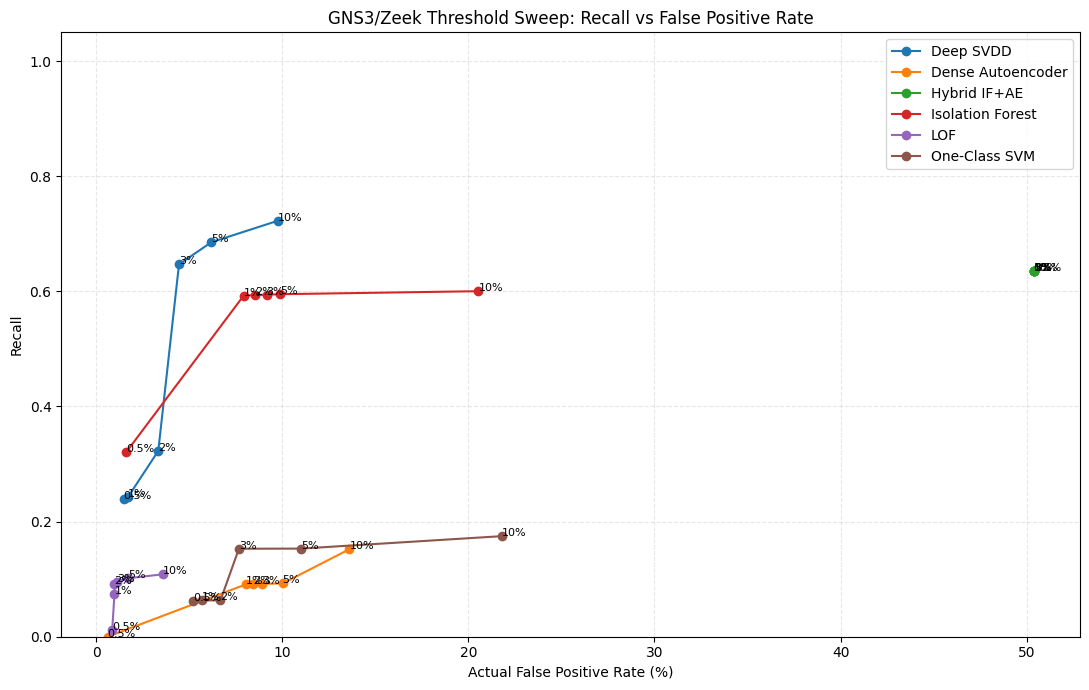

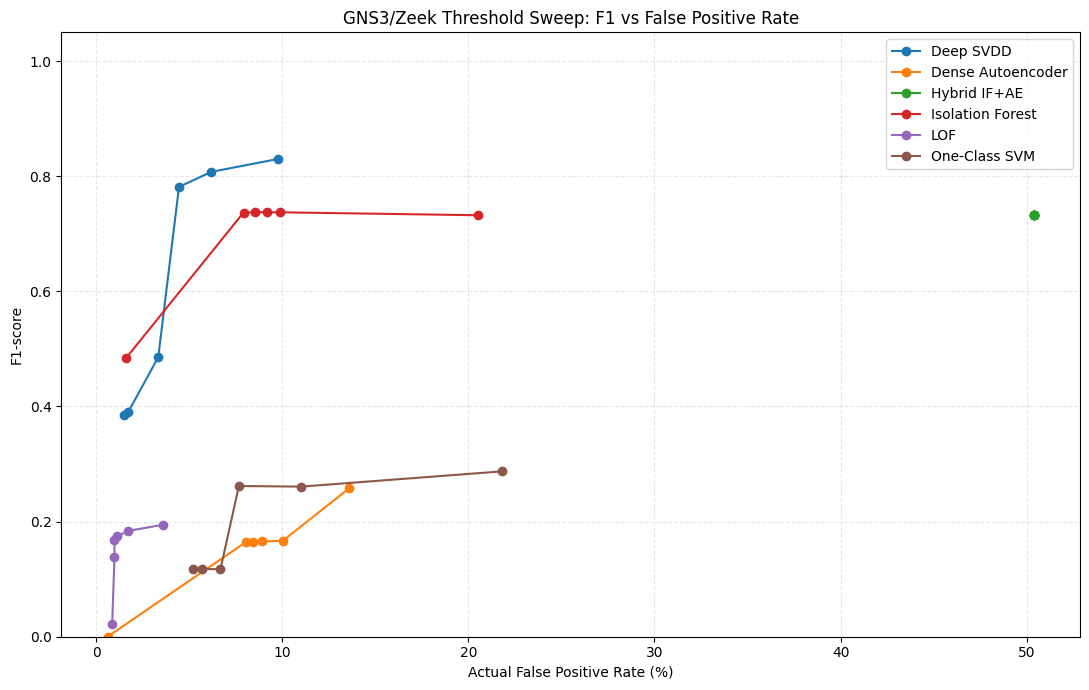

Charts saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Recall_vs_FPR.png
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_F1_vs_FPR.png


In [ ]:
# GNS3 THRESHOLD SWEEP:
# RECALL VS ACTUAL FALSE POSITIVE RATE

RECALL_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Recall_vs_FPR.png"
)


plt.figure(
    figsize=(11, 7)
)


for model_name in (
    sweep_results[
        "Model"
    ].unique()
):

    model_data = (
        sweep_results[
            sweep_results[
                "Model"
            ] == model_name
        ]
        .sort_values(
            "Budget (%)"
        )
    )


    plt.plot(
        model_data[
            "FPR (%)"
        ],
        model_data[
            "Recall"
        ],
        marker="o",
        label=model_name
    )


    for _, row in (
        model_data.iterrows()
    ):

        plt.annotate(
            f'{row["Budget (%)"]:g}%',
            (
                row["FPR (%)"],
                row["Recall"]
            ),
            fontsize=8
        )


plt.xlabel(
    "Actual False Positive Rate (%)"
)

plt.ylabel(
    "Recall"
)

plt.title(
    "GNS3/Zeek Threshold Sweep: "
    "Recall vs False Positive Rate"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    RECALL_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# F1 VS ACTUAL FALSE POSITIVE RATE

F1_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_F1_vs_FPR.png"
)


plt.figure(
    figsize=(11, 7)
)


for model_name in (
    sweep_results[
        "Model"
    ].unique()
):

    model_data = (
        sweep_results[
            sweep_results[
                "Model"
            ] == model_name
        ]
        .sort_values(
            "Budget (%)"
        )
    )


    plt.plot(
        model_data[
            "FPR (%)"
        ],
        model_data[
            "F1"
        ],
        marker="o",
        label=model_name
    )


plt.xlabel(
    "Actual False Positive Rate (%)"
)

plt.ylabel(
    "F1-score"
)

plt.title(
    "GNS3/Zeek Threshold Sweep: "
    "F1 vs False Positive Rate"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    F1_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Charts saved:"
)

print(
    RECALL_CHART_FILE
)

print(
    F1_CHART_FILE
)

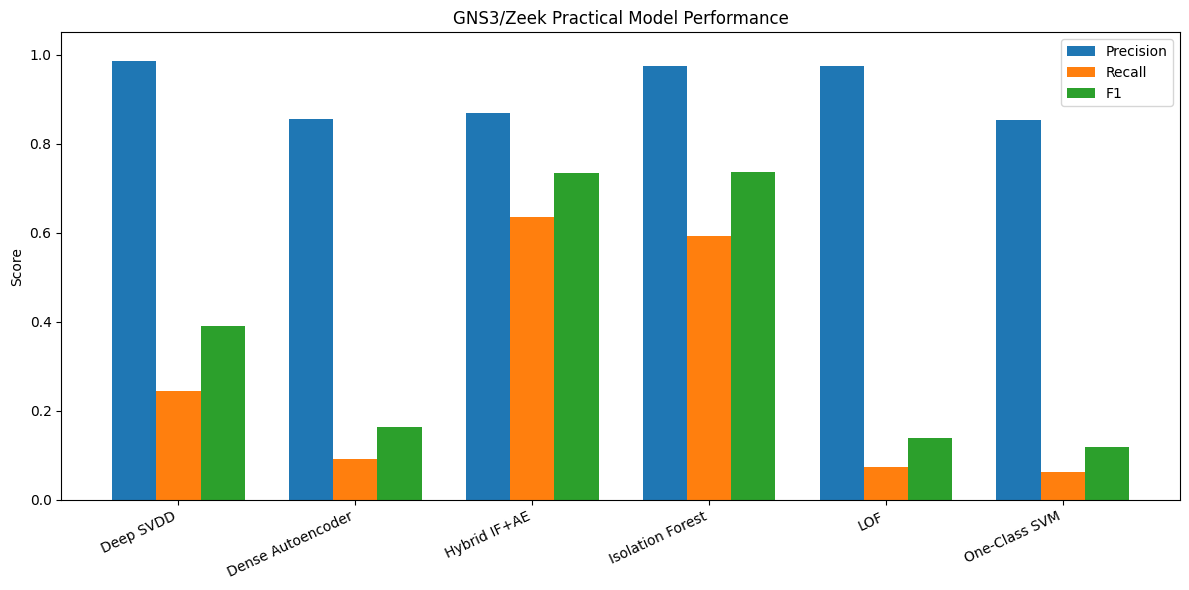

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Model_Performance.png


In [ ]:
# MODEL PERFORMANCE BAR CHART

BAR_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Model_Performance.png"
)

plot_df = comparison_1pct.copy()

x = np.arange(len(plot_df))

width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    plot_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    plot_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    plot_df["F1"],
    width,
    label="F1"
)

plt.xticks(
    x,
    plot_df["Model"],
    rotation=25,
    ha="right"
)

plt.ylim(0, 1.05)

plt.ylabel("Score")

plt.title(
    "GNS3/Zeek Practical Model Performance"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    BAR_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(BAR_CHART_FILE)

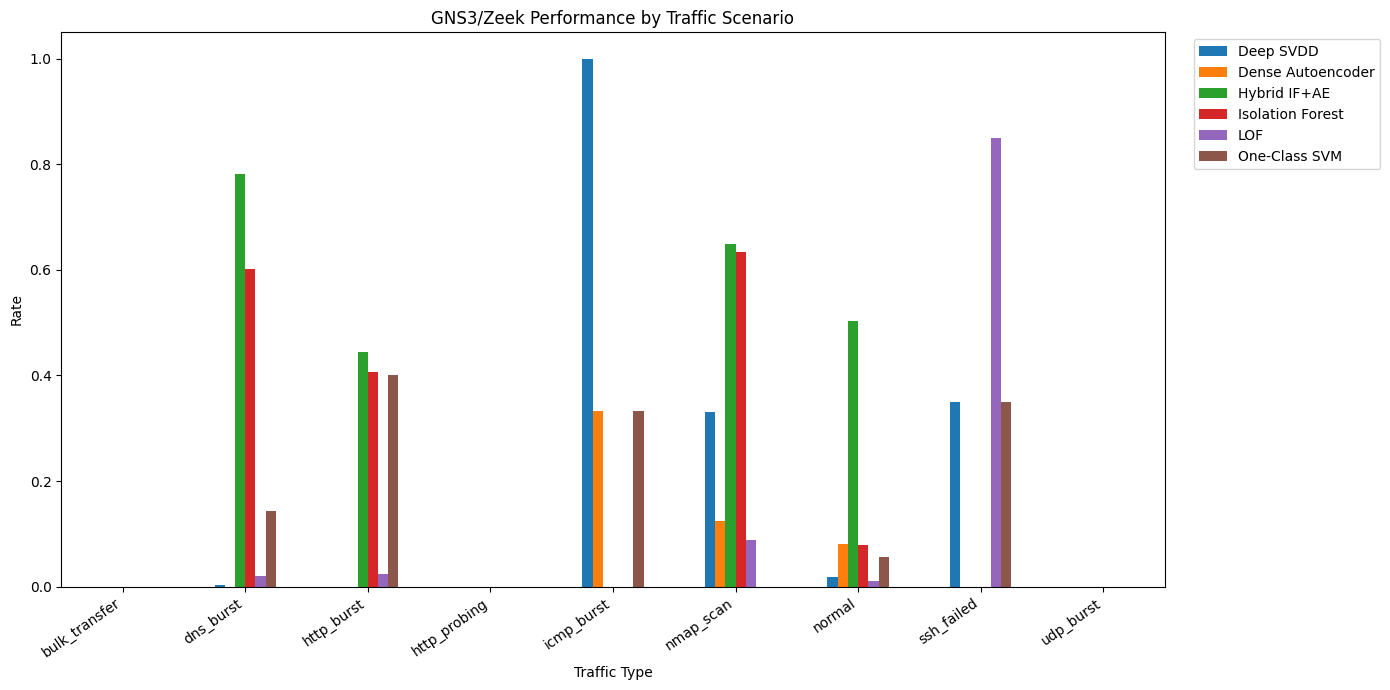

Saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Per_Scenario_Detection.png


In [ ]:
# PER-SCENARIO DETECTION / FALSE-POSITIVE CHART

SCENARIO_CHART_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Per_Scenario_Detection.png"
)


scenario_pivot = (
    scenario_results
    .pivot(
        index="Traffic Type",
        columns="Model",
        values="Rate"
    )
)


ax = scenario_pivot.plot(
    kind="bar",
    figsize=(14, 7)
)


plt.ylabel(
    "Rate"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "GNS3/Zeek Performance by Traffic Scenario"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()


plt.savefig(
    SCENARIO_CHART_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Saved:")
print(SCENARIO_CHART_FILE)

In [ ]:
# CREATE ZIP AND DOWNLOAD

import zipfile
from google.colab import files


ZIP_FILE = (
    RESULT_DIR /
    "GNS3_Zeek_Threshold_Budget_Sweep_Results.zip"
)


files_to_zip = [
    EXCEL_FILE,
    CSV_FILE,
    RECALL_CHART_FILE,
    F1_CHART_FILE,
    SCENARIO_CHART_FILE,
    THRESHOLD_FILE
]


with zipfile.ZipFile(
    ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zip_file:

    for file in files_to_zip:

        if file.exists():

            zip_file.write(
                file,
                arcname=file.name
            )

        else:

            print(
                "Skipped missing file:",
                file
            )


print(
    "ZIP created:"
)

print(
    ZIP_FILE
)


files.download(
    str(ZIP_FILE)
)

ZIP created:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/results/gns3_zeek_threshold_budget_sweep/GNS3_Zeek_Threshold_Budget_Sweep_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>